In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("F:/X ray dataset/Second Version/Data_Entry_2017.csv")
print(df.shape)
print(df.columns.tolist())

(112120, 12)
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [3]:
print(df['Finding Labels'].value_counts().head(20))

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64


In [4]:
from collections import Counter

all_labels = []
for label_str in df['Finding Labels']:
    labels = label_str.split('|')
    all_labels.extend(labels)

label_counts = Counter(all_labels)
label_counts = pd.Series(label_counts).sort_values(ascending=False)
print(label_counts)

No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


C:\Users\shamr\AppData\Local\Temp\ipykernel_12012\531732965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts_no_normal.values, y=label_counts_no_normal.index, palette='viridis')


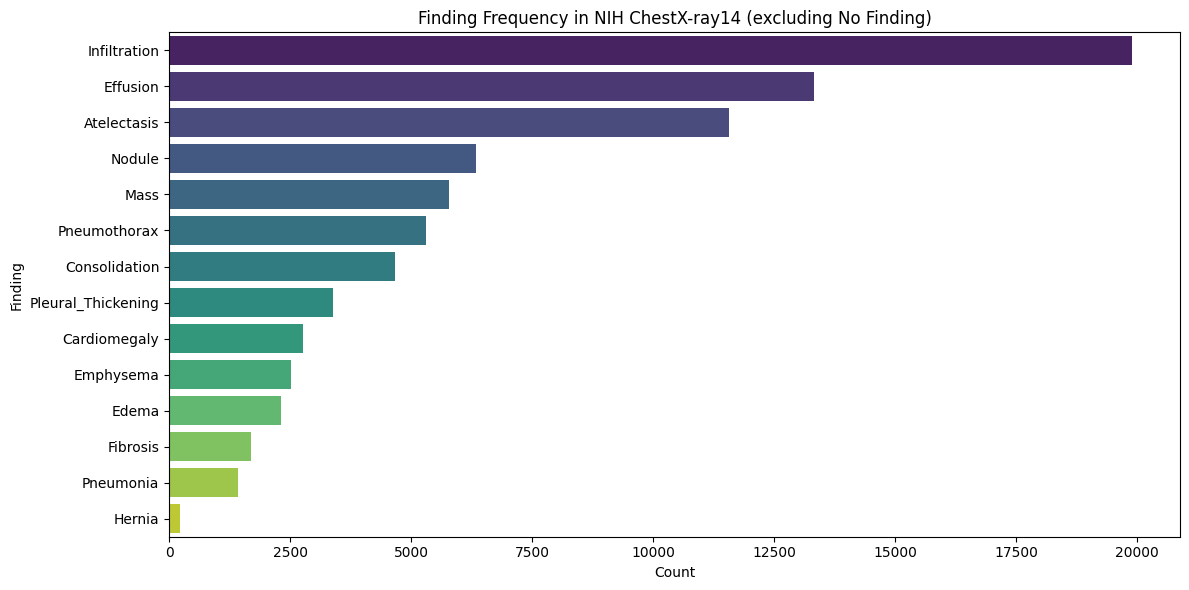

In [5]:
plt.figure(figsize=(12, 6))
label_counts_no_normal = label_counts.drop('No Finding')
sns.barplot(x=label_counts_no_normal.values, y=label_counts_no_normal.index, palette='viridis')
plt.title('Finding Frequency in NIH ChestX-ray14 (excluding No Finding)')
plt.xlabel('Count')
plt.ylabel('Finding')
plt.tight_layout()
plt.show()

In [6]:
triage_mapping = {
    'Pneumothorax':      'Critical',
    'Edema':             'Critical', 
    'Hernia':            'Critical',
    'Pneumonia':         'Critical',
    'Consolidation':     'Urgent',
    'Effusion':          'Urgent',
    'Cardiomegaly':      'Urgent',
    'Mass':              'Urgent',
    'Atelectasis':       'Urgent',
    'Nodule':            'Urgent',
    'Infiltration':      'Urgent',
    'Emphysema':         'Routine',
    'Fibrosis':          'Routine',
    'Pleural_Thickening':'Routine',
    'No Finding':        'Routine'
}

print("Critical findings:", [k for k,v in triage_mapping.items() if v == 'Critical'])
print("Urgent findings:", [k for k,v in triage_mapping.items() if v == 'Urgent'])
print("Routine findings:", [k for k,v in triage_mapping.items() if v == 'Routine'])

Critical findings: ['Pneumothorax', 'Edema', 'Hernia', 'Pneumonia']
Urgent findings: ['Consolidation', 'Effusion', 'Cardiomegaly', 'Mass', 'Atelectasis', 'Nodule', 'Infiltration']
Routine findings: ['Emphysema', 'Fibrosis', 'Pleural_Thickening', 'No Finding']


In [8]:
print(df['Patient Gender'].value_counts())
print()
print(df['Patient Age'].describe())

Patient Gender
M    63340
F    48780
Name: count, dtype: int64

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [9]:
print("Ages above 100:", (df['Patient Age'] > 100).sum())
print("Ages below 1:", (df['Patient Age'] < 1).sum())

Ages above 100: 16
Ages below 1: 0


In [10]:
print(df['View Position'].value_counts())

View Position
PA    67310
AP    44810
Name: count, dtype: int64


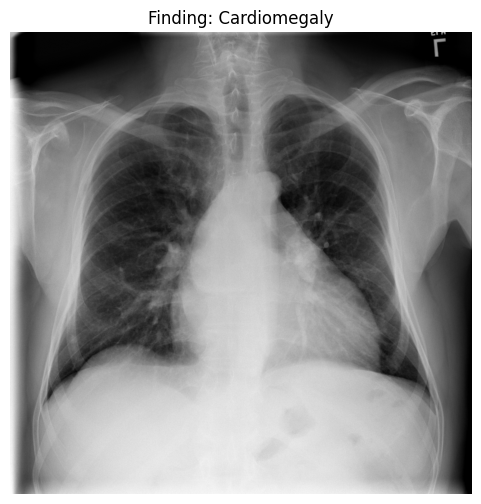

Image size: (1024, 1024)


In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Find the first image
image_folder = "F:/X ray dataset/Second Version"
first_image = df['Image Index'].iloc[0]

# Search in subfolders
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(image_folder, folder, "images", first_image)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"Finding: {df['Finding Labels'].iloc[0]}")
        plt.axis('off')
        plt.show()
        print(f"Image size: {img.size}")
        break

In [12]:
df['num_findings'] = df['Finding Labels'].apply(lambda x: len(x.split('|')))
print(df['num_findings'].value_counts().sort_index())

num_findings
1    91324
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64


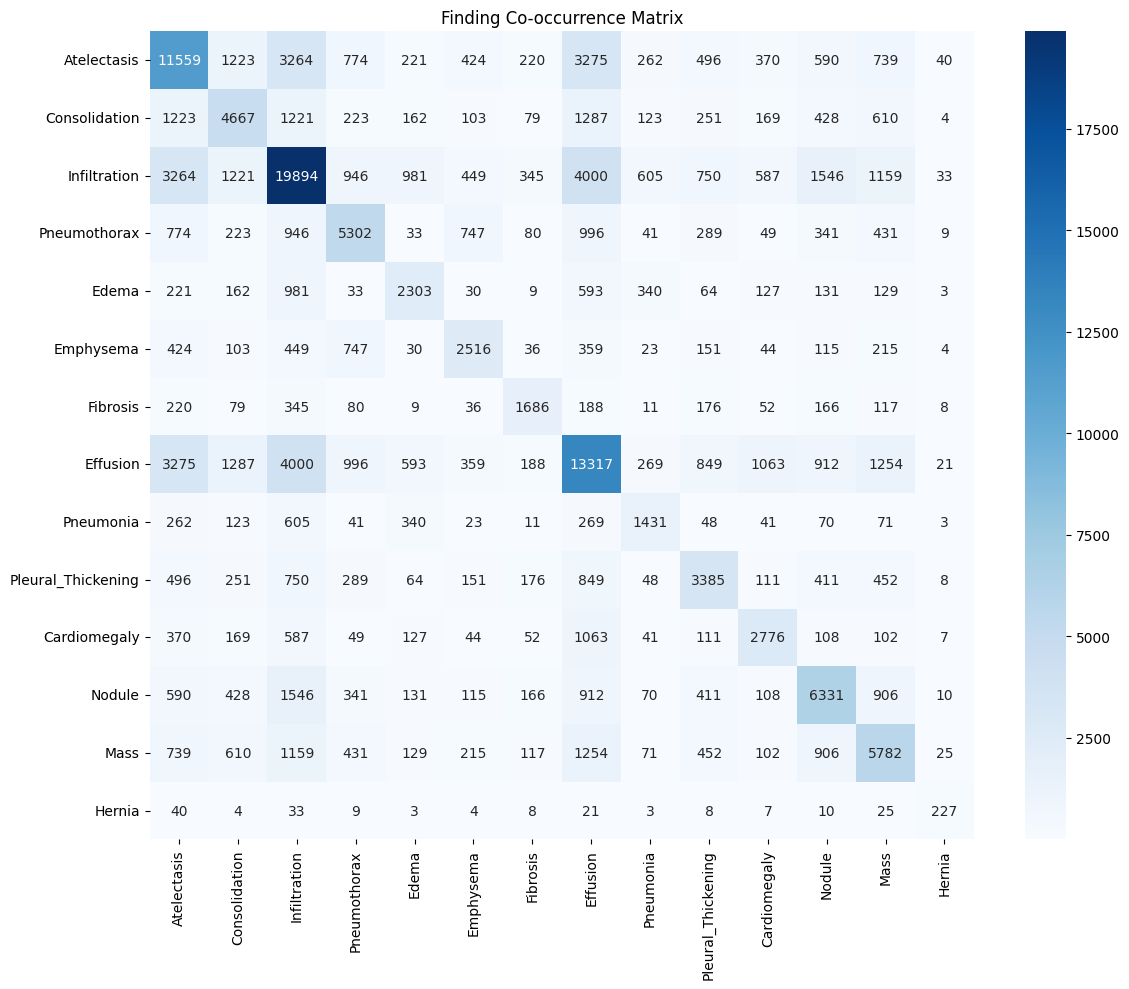

In [13]:

# Create binary label columns
labels = ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 
          'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
          'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia']

for label in labels:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# Co-occurrence matrix
co_occurrence = df[labels].T.dot(df[labels])

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues')
plt.title('Finding Co-occurrence Matrix')
plt.tight_layout()
plt.show()


In [31]:
import sys
sys.path.append('D:/cxr-triage')

from src.data.dataset import ChestXrayDataset

dataset = ChestXrayDataset(
    csv_path="F:/X ray dataset/Second Version/Data_Entry_2017.csv",
    image_root="F:/X ray dataset/Second Version"
)

print(f"Dataset size: {len(dataset)}")
image, label = dataset[0]
print(f"Image type: {type(image)}")
print(f"Label vector: {label}")
print(f"Label shape: {label.shape}")

Dataset size: 112120
Image type: <class 'PIL.Image.Image'>
Label vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Label shape: (14,)


In [30]:
import importlib
import sys

# Remove cached modules
mods_to_remove = [key for key in sys.modules if 'src' in key]
for mod in mods_to_remove:
    del sys.modules[mod]

In [32]:
from src.data.transforms import get_train_transforms, get_val_transforms

train_transform = get_train_transforms()
val_transform = get_val_transforms()

# Test on our dataset
dataset = ChestXrayDataset(
    csv_path="F:/X ray dataset/Second Version/Data_Entry_2017.csv",
    image_root="F:/X ray dataset/Second Version",
    transform=train_transform
)

image, label = dataset[0]
print(f"Image tensor shape: {image.shape}")
print(f"Image min: {image.min():.3f}")
print(f"Image max: {image.max():.3f}")
print(f"Label: {label}")

Image tensor shape: torch.Size([3, 224, 224])
Image min: -2.118
Image max: 1.943
Label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [33]:
from src.models.densenet import DenseNetModel
import torch

model = DenseNetModel(num_classes=14, pretrained=True)
print(model)

# Test with a dummy input
dummy = torch.randn(1, 3, 224, 224)
output = model(dummy)
print(f"Output shape: {output.shape}")
print(f"Output values: {output}")

c:\Users\shamr\anaconda3\envs\cxr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\shamr\anaconda3\envs\cxr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\shamr/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:06<00:00, 5.08MB/s]


DenseNetModel(
  (model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum

In [34]:
import pandas as pd

train_val_list = pd.read_csv(
    "F:/X ray dataset/Second Version/train_val_list.txt", 
    header=None, 
    names=['Image Index']
)
test_list = pd.read_csv(
    "F:/X ray dataset/Second Version/test_list.txt", 
    header=None, 
    names=['Image Index']
)

print(f"Train+Val images: {len(train_val_list)}")
print(f"Test images: {len(test_list)}")

# Check for leakage
overlap = set(train_val_list['Image Index']) & set(test_list['Image Index'])
print(f"Overlap between train and test: {len(overlap)}")

Train+Val images: 86524
Test images: 25596
Overlap between train and test: 0


In [35]:
df = pd.read_csv("F:/X ray dataset/Second Version/Data_Entry_2017.csv")

# Get train+val and test dataframes
train_val_df = df[df['Image Index'].isin(train_val_list['Image Index'])]
test_df = df[df['Image Index'].isin(test_list['Image Index'])]

# Split train+val by patient ID — 80% train, 20% val
patient_ids = train_val_df['Patient ID'].unique()
print(f"Total unique patients in train+val: {len(patient_ids)}")

import numpy as np
np.random.seed(42)
np.random.shuffle(patient_ids)

split = int(0.8 * len(patient_ids))
train_patients = set(patient_ids[:split])
val_patients = set(patient_ids[split:])

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)]
val_df = train_val_df[train_val_df['Patient ID'].isin(val_patients)]

print(f"Train images: {len(train_df)}")
print(f"Val images: {len(val_df)}")
print(f"Test images: {len(test_df)}")

# Verify no patient overlap between train and val
overlap = set(train_df['Patient ID']) & set(val_df['Patient ID'])
print(f"Patient overlap train/val: {len(overlap)}")

Total unique patients in train+val: 28008
Train images: 68918
Val images: 17606
Test images: 25596
Patient overlap train/val: 0


In [36]:
import os

os.makedirs('D:/cxr-triage/data/processed', exist_ok=True)

train_df.to_csv('D:/cxr-triage/data/processed/train.csv', index=False)
val_df.to_csv('D:/cxr-triage/data/processed/val.csv', index=False)
test_df.to_csv('D:/cxr-triage/data/processed/test.csv', index=False)

print("Splits saved successfully")
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Splits saved successfully
Train: 68918
Val: 17606
Test: 25596


In [37]:
import torch
import pandas as pd
import sys
sys.path.append('D:/cxr-triage')

from src.training.losses import WeightedBCELoss, FocalLoss, get_pos_weights

train_df = pd.read_csv('D:/cxr-triage/data/processed/train.csv')

labels = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pos_weights = get_pos_weights(train_df, labels, device)

print("Positive weights per finding:")
for label, weight in zip(labels, pos_weights):
    print(f"{label}: {weight:.1f}")

Positive weights per finding:
Atelectasis: 9.4
Consolidation: 29.1
Infiltration: 5.3
Pneumothorax: 31.4
Edema: 62.2
Emphysema: 60.2
Fibrosis: 68.4
Effusion: 9.1
Pneumonia: 96.6
Pleural_Thickening: 37.0
Cardiomegaly: 50.1
Nodule: 17.3
Mass: 20.2
Hernia: 593.1


In [38]:
# Test both loss functions
wbce = WeightedBCELoss(pos_weights)
focal = FocalLoss(gamma=2.0, pos_weights=pos_weights)

# Dummy predictions and targets
dummy_preds = torch.randn(16, 14).to(device)
dummy_targets = torch.zeros(16, 14).to(device)
dummy_targets[0][3] = 1.0  # Pneumothorax in first image

wbce_loss = wbce(dummy_preds, dummy_targets)
focal_loss = focal(dummy_preds, dummy_targets)

print(f"Weighted BCE Loss: {wbce_loss.item():.4f}")
print(f"Focal Loss: {focal_loss.item():.4f}")
print("Both loss functions working correctly")

Weighted BCE Loss: 0.8979
Focal Loss: 0.4313
Both loss functions working correctly


In [49]:
import sys
sys.path.append('D:/cxr-triage')

# Clear cache
mods_to_remove = [key for key in sys.modules if 'src' in key]
for mod in mods_to_remove:
    del sys.modules[mod]

import torch
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader

from src.data.dataset import ChestXrayDataset
from src.data.transforms import get_train_transforms
from src.models.densenet import DenseNetModel
from src.training.losses import WeightedBCELoss, get_pos_weights

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_ROOT = "F:/X ray dataset/Second Version"

train_df = pd.read_csv('D:/cxr-triage/data/processed/train.csv')

train_dataset = ChestXrayDataset(
    csv_path=None,
    image_root=IMAGE_ROOT,
    transform=get_train_transforms()
)
train_dataset.df = train_df

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

model = DenseNetModel(num_classes=14, pretrained=True).to(DEVICE)
pos_weights = get_pos_weights(train_df, LABELS, DEVICE)
criterion = WeightedBCELoss(pos_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler('cuda')

# Run just 2 batches
model.train()
for batch_idx, (images, labels) in enumerate(train_loader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    
    optimizer.zero_grad()
    
    with torch.amp.autocast('cuda'):
        predictions = model(images)
        loss = criterion(predictions, labels)
    
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    
    print(f"Batch {batch_idx+1}, Loss: {loss.item():.4f}")
    
    if batch_idx == 1:
        break

print("Sanity check passed!")

Batch 1, Loss: 1.1738
Batch 2, Loss: 1.6064
Sanity check passed!


In [47]:
import importlib
import sys
mods_to_remove = [key for key in sys.modules if 'src' in key]
for mod in mods_to_remove:
    del sys.modules[mod]

In [51]:
with open('D:/cxr-triage/src/training/train.py', 'r') as f:
    content = f.read()

content = content.replace(
    'from torch.cuda.amp import GradScaler, autocast',
    'from torch.amp import GradScaler, autocast'
)
content = content.replace(
    'scaler = GradScaler()',
    "scaler = GradScaler('cuda')"
)
content = content.replace(
    'with autocast():',
    "with autocast('cuda'):"
)

with open('D:/cxr-triage/src/training/train.py', 'w') as f:
    f.write(content)

print("Fixed!")

Fixed!


In [54]:
import sys
sys.path.append('D:/cxr-triage')

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from src.data.dataset import ChestXrayDataset
from src.data.transforms import get_val_transforms
from src.models.densenet import DenseNetModel

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test set
test_df = pd.read_csv('D:/cxr-triage/data/processed/test.csv')

test_dataset = ChestXrayDataset(
    csv_path=None,
    image_root="F:/X ray dataset/Second Version",
    transform=get_val_transforms()
)
test_dataset.df = test_df

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Load best model
model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load('D:/cxr-triage/checkpoints/best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"Best val AUC was: {checkpoint['best_auc']:.4f}")

Loaded model from epoch 28
Best val AUC was: 0.7592


In [55]:
from tqdm import tqdm

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        with torch.amp.autocast('cuda'):
            predictions = model(images)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Per-class AUC
print(f"\n{'Finding':<25} {'AUC':>8} {'Triage Tier':>15}")
print("-" * 50)

triage_map = {
    'Pneumothorax': 'Critical',
    'Edema': 'Critical',
    'Hernia': 'Critical',
    'Pneumonia': 'Critical',
    'Consolidation': 'Urgent',
    'Effusion': 'Urgent',
    'Cardiomegaly': 'Urgent',
    'Mass': 'Urgent',
    'Atelectasis': 'Urgent',
    'Nodule': 'Urgent',
    'Infiltration': 'Urgent',
    'Emphysema': 'Routine',
    'Fibrosis': 'Routine',
    'Pleural_Thickening': 'Routine'
}

auc_scores = {}
for i, label in enumerate(LABELS):
    auc = roc_auc_score(all_targets[:, i], all_predictions[:, i])
    auc_scores[label] = auc
    tier = triage_map[label]
    print(f"{label:<25} {auc:>8.4f} {tier:>15}")

print("-" * 50)
print(f"{'Mean AUC':<25} {np.mean(list(auc_scores.values())):>8.4f}")

Evaluating: 100%|██████████| 1600/1600 [03:33<00:00,  7.49it/s]


Finding                        AUC     Triage Tier
--------------------------------------------------
Atelectasis                 0.7039          Urgent
Consolidation               0.7049          Urgent
Infiltration                0.6806          Urgent
Pneumothorax                0.7690        Critical
Edema                       0.8059        Critical
Emphysema                   0.7249         Routine
Fibrosis                    0.7447         Routine
Effusion                    0.7555          Urgent
Pneumonia                   0.6306        Critical
Pleural_Thickening          0.7013         Routine
Cardiomegaly                0.8470          Urgent
Nodule                      0.6267          Urgent
Mass                        0.6857          Urgent
Hernia                      0.7430        Critical
--------------------------------------------------
Mean AUC                    0.7231


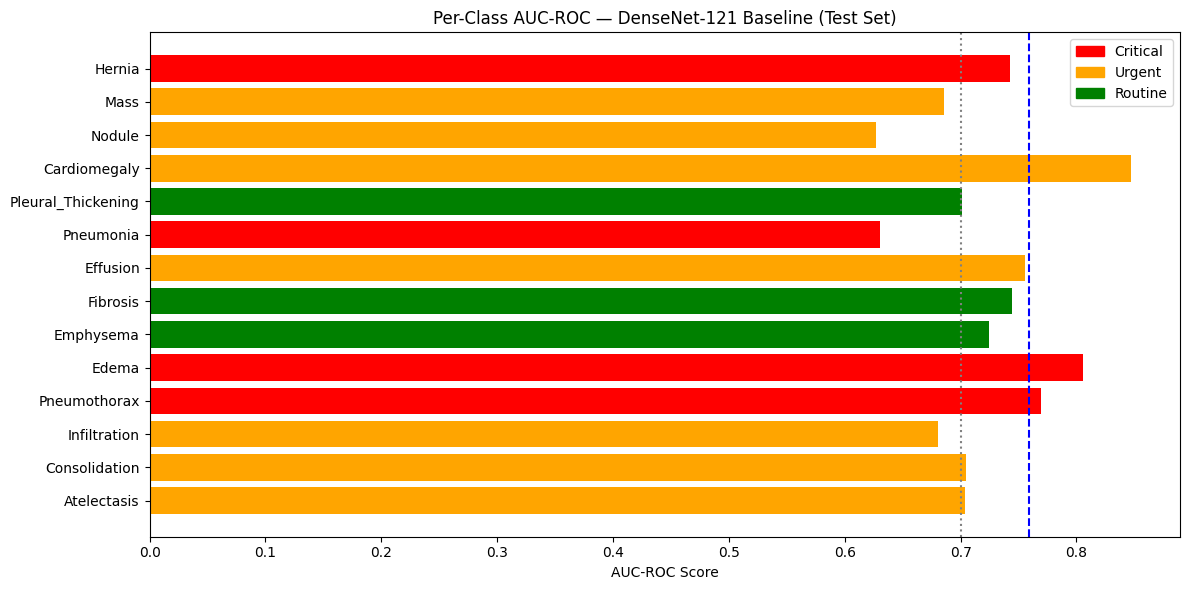

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = []
for label in LABELS:
    tier = triage_map[label]
    if tier == 'Critical':
        colors.append('red')
    elif tier == 'Urgent':
        colors.append('orange')
    else:
        colors.append('green')

plt.figure(figsize=(12, 6))
bars = plt.barh(LABELS, [auc_scores[l] for l in LABELS], color=colors)
plt.axvline(x=0.7592, color='blue', linestyle='--', label='Mean AUC (0.7592)')
plt.axvline(x=0.7, color='gray', linestyle=':', label='AUC 0.70 threshold')
plt.xlabel('AUC-ROC Score')
plt.title('Per-Class AUC-ROC — DenseNet-121 Baseline (Test Set)')

red = mpatches.Patch(color='red', label='Critical')
orange = mpatches.Patch(color='orange', label='Urgent')
green = mpatches.Patch(color='green', label='Routine')
plt.legend(handles=[red, orange, green])
plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/baseline_auc.png', dpi=150)
plt.show()

In [59]:
import sys
sys.path.append('D:/cxr-triage')

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from src.data.dataset import ChestXrayDataset
from src.data.transforms import get_val_transforms
from src.models.densenet import DenseNetModel

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test set
test_df = pd.read_csv('D:/cxr-triage/data/processed/test.csv')

test_dataset = ChestXrayDataset(
    csv_path=None,
    image_root="F:/X ray dataset/Second Version",
    transform=get_val_transforms()
)
test_dataset.df = test_df

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Load best model
model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load("D:/cxr-triage/checkpoints/focal_loss/best_model.pth", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"Best val AUC was: {checkpoint['best_auc']:.4f}")

Loaded model from epoch 27
Best val AUC was: 0.7652


In [60]:
from tqdm import tqdm

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        with torch.amp.autocast('cuda'):
            predictions = model(images)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Per-class AUC
print(f"\n{'Finding':<25} {'AUC':>8} {'Triage Tier':>15}")
print("-" * 50)

triage_map = {
    'Pneumothorax': 'Critical',
    'Edema': 'Critical',
    'Hernia': 'Critical',
    'Pneumonia': 'Critical',
    'Consolidation': 'Urgent',
    'Effusion': 'Urgent',
    'Cardiomegaly': 'Urgent',
    'Mass': 'Urgent',
    'Atelectasis': 'Urgent',
    'Nodule': 'Urgent',
    'Infiltration': 'Urgent',
    'Emphysema': 'Routine',
    'Fibrosis': 'Routine',
    'Pleural_Thickening': 'Routine'
}

auc_scores = {}
for i, label in enumerate(LABELS):
    auc = roc_auc_score(all_targets[:, i], all_predictions[:, i])
    auc_scores[label] = auc
    tier = triage_map[label]
    print(f"{label:<25} {auc:>8.4f} {tier:>15}")

print("-" * 50)
print(f"{'Mean AUC':<25} {np.mean(list(auc_scores.values())):>8.4f}")

Evaluating: 100%|██████████| 1600/1600 [05:08<00:00,  5.19it/s]


Finding                        AUC     Triage Tier
--------------------------------------------------
Atelectasis                 0.7090          Urgent
Consolidation               0.6996          Urgent
Infiltration                0.6752          Urgent
Pneumothorax                0.7719        Critical
Edema                       0.8045        Critical
Emphysema                   0.7282         Routine
Fibrosis                    0.7377         Routine
Effusion                    0.7505          Urgent
Pneumonia                   0.6522        Critical
Pleural_Thickening          0.7134         Routine
Cardiomegaly                0.8479          Urgent
Nodule                      0.6234          Urgent
Mass                        0.6821          Urgent
Hernia                      0.7624        Critical
--------------------------------------------------
Mean AUC                    0.7256


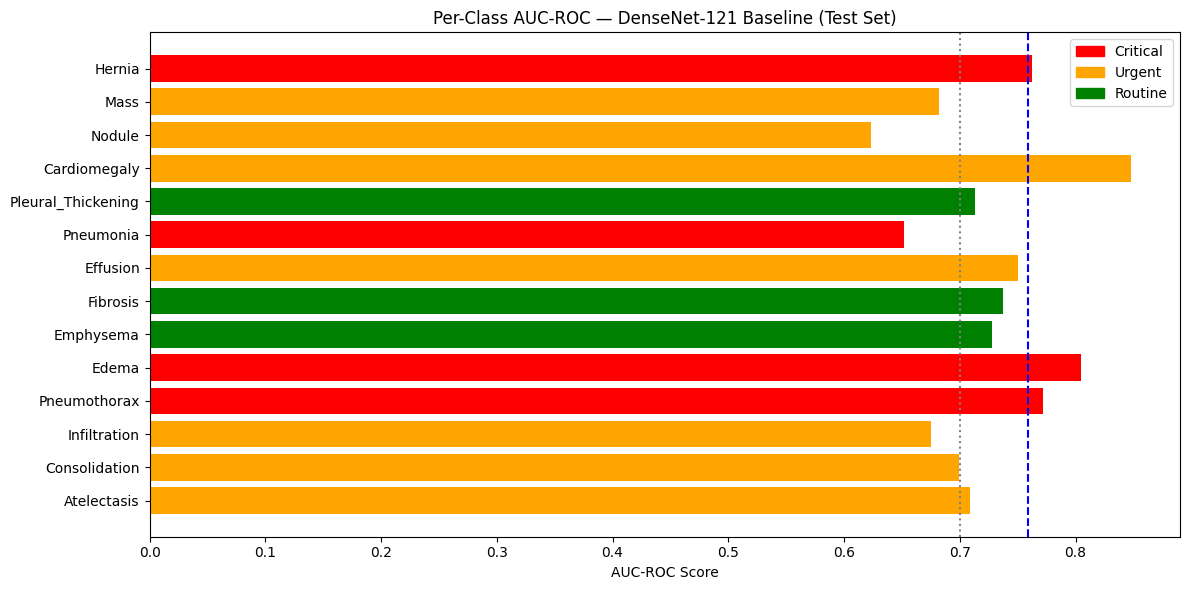

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = []
for label in LABELS:
    tier = triage_map[label]
    if tier == 'Critical':
        colors.append('red')
    elif tier == 'Urgent':
        colors.append('orange')
    else:
        colors.append('green')

plt.figure(figsize=(12, 6))
bars = plt.barh(LABELS, [auc_scores[l] for l in LABELS], color=colors)
plt.axvline(x=0.7592, color='blue', linestyle='--', label='Mean AUC (0.7592)')
plt.axvline(x=0.7, color='gray', linestyle=':', label='AUC 0.70 threshold')
plt.xlabel('AUC-ROC Score')
plt.title('Per-Class AUC-ROC — DenseNet-121 Loss (Test Set)')

red = mpatches.Patch(color='red', label='Critical')
orange = mpatches.Patch(color='orange', label='Urgent')
green = mpatches.Patch(color='green', label='Routine')
plt.legend(handles=[red, orange, green])
plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/baseline_auc.png', dpi=150)
plt.show()